In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os
import shutil
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from google.colab import files
import warnings
import pydot
import graphviz
import gdown


# Suppress warnings and configure TensorFlow logging
warnings.filterwarnings('ignore', category=FutureWarning)
tf.get_logger().setLevel('ERROR')


In [ ]:
# Check for GPU and set device
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
!pip install kaggle

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d dansbecker/food-101

Dataset URL: https://www.kaggle.com/datasets/dansbecker/food-101
License(s): other
100% 9.37G/9.38G [07:22<00:00, 23.0MB/s]
100% 9.38G/9.38G [07:22<00:00, 22.7MB/s]


In [ ]:
import zipfile

with zipfile.ZipFile('food-101.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/food-101')

In [ ]:
# Split data into training and testing set

# Define the base directory and create train and validation directories
base_dir = '/content/food-101/food-101/food-101/images'
train_dir = '/content/food-101/food-101/food-101/train'
val_dir = '/content/food-101/food-101/food-101/validation'

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

# Split the data into training and validation sets
for category in os.listdir(base_dir):
    category_path = os.path.join(base_dir, category)
    if os.path.isdir(category_path):
        os.makedirs(os.path.join(train_dir, category), exist_ok=True)
        os.makedirs(os.path.join(val_dir, category), exist_ok=True)

        images = os.listdir(category_path)
        random.shuffle(images)

        split_index = int(0.7 * len(images))
        train_images = images[:split_index]
        val_images = images[split_index:]

        for img in train_images:
            shutil.move(os.path.join(category_path, img), os.path.join(train_dir, category))

        for img in val_images:
            shutil.move(os.path.join(category_path, img), os.path.join(val_dir, category))


In [ ]:
# Data augmentation and preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)


Found 70700 images belonging to 101 classes.
Found 30300 images belonging to 101 classes.


In [ ]:
# Display random food images
class_names = list(train_generator.class_indices.keys())
images, labels = next(train_generator)
plt.figure(figsize=(10, 10))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i].astype("uint8"))
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis('off')
plt.show()


NameError: name 'train_generator' is not defined

NameError: name 'ResNet101' is not defined

In [ ]:
# Load ResNet50 model with pre-trained weights and fine-tune it
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(len(train_generator.class_indices), activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)

# Freeze the layers of ResNet50 except the top layers
for layer in base_model.layers:
    layer.trainable = False

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
# Train the model
with tf.device('/GPU:0'):
  history = model.fit(
      train_generator,
      steps_per_epoch=train_generator.samples // train_generator.batch_size,
      validation_data=val_generator,
      validation_steps=val_generator.samples // val_generator.batch_size,
      epochs=10
  )

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2209/2209 ━━━━━━━━━━━━━━━━━━━━ 1174s 524ms/step - accuracy: 0.3792 - loss: 2.5934 - val_accuracy: 0.5433 - val_loss: 1.7581
Epoch 2/10
   1/2209 ━━━━━━━━━━━━━━━━━━━━ 2:58 81ms/step - accuracy: 0.5312 - loss: 1.9670

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


2209/2209 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5312 - loss: 1.9670 - val_accuracy: 0.3929 - val_loss: 2.1232
Epoch 3/10
 604/2209 ━━━━━━━━━━━━━━━━━━━━ 11:50 443ms/step - accuracy: 0.5431 - loss: 1.7522

In [ ]:
# Validate the model
loss, accuracy = model.evaluate(val_generator)
print(f'Validation accuracy: {accuracy * 100:.2f}%')

947/947 ━━━━━━━━━━━━━━━━━━━━ 110s 116ms/step - accuracy: 0.1521 - loss: 3.7467
Validation accuracy: 14.95%


In [ ]:
# Save the model
model.save('food_101_classification_model.h5')

# Download the model
files.download('food_101_classification_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Upload a new image from your computer
uploaded_image = files.upload()

# Preprocess the new image
img_path = next(iter(uploaded_image))  # Get the uploaded image file path
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Predict the class of the new image
predictions = model.predict(img_array)
predicted_class = list(train_generator.class_indices.keys())[np.argmax(predictions)]

# Display the image and prediction
plt.imshow(img)
plt.title(f'Predicted: {predicted_class}')
plt.axis('off')
plt.show()


Saving ic.jpg to ic.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


NameError: name 'train_generator' is not defined

In [ ]:
from google.colab import drive

# Mount the drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
model_path = '/content/drive/My Drive/Colab Notebooks/food_101_classification_model.h5'


In [ ]:
from tensorflow.keras.models import load_model

# Load the model from Drive
model = load_model(model_path)
print("Model loaded successfully!")


Model loaded successfully!


In [ ]:
import os
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:
# Upload a new image from your computer
uploaded_image = files.upload()

# Preprocess the new image
img_path = next(iter(uploaded_image))  # Get the uploaded image file path
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

Saving ic.jpg to ic.jpg


In [ ]:
# Predict the class of the image
predictions = model.predict(img_array)
food_image_dir = '/content/food-101/food-101/food-101/images'
# Replace `train_generator.class_indices.keys()` with your class indices
class_indices = sorted(os.listdir(food_image_dir))  # Update this with your actual classes
predicted_class = class_indices[np.argmax(predictions)]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [ ]:
# Load the dataset
file_path = '/content/drive/My Drive/Colab Notebooks/our_dataset.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')

# Define the title to search for
title_input = predicted_class


Ingredients:

canned chickpeas (garbanzo beans)'
'tahini'
'lemon juice'
'garlic'
'olive oil'
'ground cumin'
'salt'
'black pepper'
'water'
'paprika (optional)'
'parsley (optional)'

Instructions:
 Prepare the Ingredients: Drain and rinse 1 can (15 oz) of chickpeas (garbanzo beans) and set aside. Reserve a few whole chickpeas for garnish if desired. Juice 1 lemon. Mince 1 small garlic clove. Measure 1/4 cup tahini (sesame paste) and 2 tablespoons olive oil.

Blend the Hummus: In a food processor, combine the chickpeas, lemon juice, tahini, minced garlic, 1/2 teaspoon salt, and 1/4 teaspoon ground cumin (optional). Add 2 tablespoons of water or more for desired consistency. Blend until smooth. If the hummus is too thick, add more water a tablespoon at a time until you reach your preferred texture.

Adjust Seasoning: Taste the hummus and adjust the seasoning by adding more salt, lemon juice, or cumin if needed. You can also add 1 tablespoon of olive oil for extra creaminess.

Serve: Trans

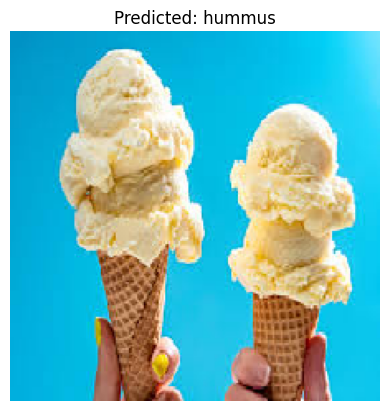

In [ ]:
# Filter the DataFrame by title
result = df[df['Recipe Name'].str.contains(title_input, case=False, na=False)]

if not result.empty:
    print("\nIngredients:\n")
    ingredients = result['Ingredients'].values[0].split(',')
    for ingredient in ingredients:
        print(ingredient.strip())
    print("\nInstructions:\n",result['Instructions'].values[0])
else:
    print("Recipe not found.")
# Display the result
print(f"Predicted class: {predicted_class}")
plt.imshow(img)
plt.title(f"Predicted: {predicted_class}")
plt.axis('off')
plt.show()